In [3]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [4]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment('nyc-taxi-experiment')

2025/12/28 08:21:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/28 08:21:51 INFO mlflow.store.db.utils: Updating database tables
2025/12/28 08:21:51 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/28 08:21:51 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/28 08:21:51 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/28 08:21:51 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/mlops-zoomcamp/experiment_tracking/mlruns/1', creation_time=1766823082109, experiment_id='1', last_update_time=1766823082109, lifecycle_stage='active', name='nyc-taxi-experiment', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [5]:
data = pd.read_parquet('./data/green_tripdata_2025-01.parquet')
data.lpep_pickup_datetime = pd.to_datetime(data.lpep_pickup_datetime)
data.lpep_dropoff_datetime = pd.to_datetime(data.lpep_dropoff_datetime)
data['duration'] = data.lpep_dropoff_datetime - data.lpep_pickup_datetime
data.duration = data.duration.apply(lambda td: td.total_seconds() / 60)

data = data[(data.duration >= 1) & (data.duration <= 60)]
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
data[categorical] = data[categorical].astype(str)

In [6]:
data.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0,14.183333
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0,5.883333
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0,1.866667
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0,15.466667
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0,36.083333


In [7]:
train_dicts = data[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = data[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)

44.94737839177094

/tmp/ipykernel_99221/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_99221/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


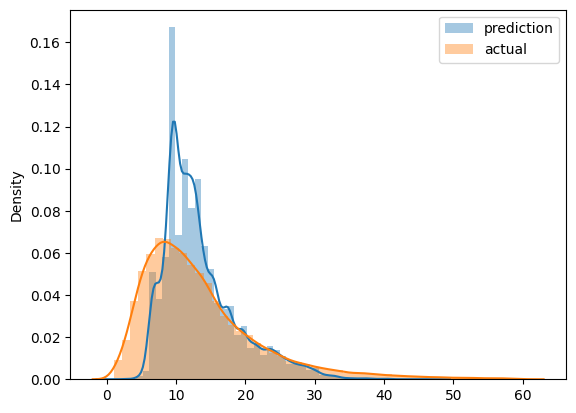

In [8]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [9]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [10]:
df_train = read_dataframe('./data/green_tripdata_2025-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2025-02.parquet')

In [11]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [12]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [13]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

37.19629658380478

In [15]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [17]:
with mlflow.start_run():
    mlflow.set_tag('Developer', 'Victor')
    mlflow.log_param('train_data_path', './data/green_tripdata_2025-01.parquet')
    mlflow.log_param('test_data_path', './data/green_tripdata_2025-02.parquet')

    alpha = 0.1
    mlflow.log_param('alpha', alpha)
    lr = Lasso(alpha=alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)
    rmse = mean_squared_error(y_pred, y_val)
    mlflow.log_metric('rmse', rmse)

    mlflow.log_artifact(local_path='models/lin_reg.bin', artifact_path='models_pickle')


In [38]:
import xgboost
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

train = xgboost.DMatrix(X_train, label=y_train)
valid = xgboost.DMatrix(X_val, label=y_val)

def objective(params):
    with mlflow.start_run():
        mlflow.set_tag('model', 'xgboost')
        mlflow.log_params(params)
        booster = xgboost.train(params=params, dtrain=train, num_boost_round=1000, evals=[(valid, 'validation')])
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred)
        mlflow.log_metric('rmse', rmse)
    
    return {'loss': rmse, 'status':STATUS_OK }

In [41]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

batch_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=Trials( )
)

[0]	validation-rmse:6.00547                           
[1]	validation-rmse:5.62334                           
  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/envs/exp_tracking/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [07:12:09] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)



[2]	validation-rmse:5.55278                           
[3]	validation-rmse:5.53508                           
[4]	validation-rmse:5.52377                           
[5]	validation-rmse:5.51442                           
[6]	validation-rmse:5.50857                           
[7]	validation-rmse:5.50000                           
[8]	validation-rmse:5.49340                           
[9]	validation-rmse:5.49006                           
[10]	validation-rmse:5.48623                          
[11]	validation-rmse:5.47507                          
[12]	validation-rmse:5.47088                          
[13]	validation-rmse:5.46847                          
[14]	validation-rmse:5.46456                          
[15]	validation-rmse:5.45783                          
[16]	validation-rmse:5.45604                          
[17]	validation-rmse:5.44817                          
[18]	validation-rmse:5.44571                          
[19]	validation-rmse:5.43937                          
[20]	valid

/home/codespace/anaconda3/envs/exp_tracking/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [07:12:41] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)



[3]	validation-rmse:7.39223                                                     
[4]	validation-rmse:7.10617                                                     
[5]	validation-rmse:6.86027                                                     
[6]	validation-rmse:6.65413                                                     
[7]	validation-rmse:6.48056                                                     
[8]	validation-rmse:6.33395                                                     
[9]	validation-rmse:6.20916                                                     
[10]	validation-rmse:6.10574                                                    
[11]	validation-rmse:6.01903                                                    
[12]	validation-rmse:5.94784                                                    
[13]	validation-rmse:5.88633                                                    
[14]	validation-rmse:5.83532                                                    
[15]	validation-rmse:5.79282

...

/home/codespace/anaconda3/envs/exp_tracking/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [07:22:07] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)



[0]	validation-rmse:8.14547                                                      
[1]	validation-rmse:7.41270                                                      
[2]	validation-rmse:6.85997                                                      
[3]	validation-rmse:6.45077                                                      
[4]	validation-rmse:6.15244                                                      
[5]	validation-rmse:5.93663                                                      
[6]	validation-rmse:5.78291                                                      
[7]	validation-rmse:5.67220                                                      
[8]	validation-rmse:5.59335                                                      
[9]	validation-rmse:5.53834                                                      
[10]	validation-rmse:5.49990                                                     
[11]	validation-rmse:5.47208                                                     
[12]	validation-

/home/codespace/anaconda3/envs/exp_tracking/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [07:25:45] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)



[0]	validation-rmse:5.55478                                                      
[1]	validation-rmse:5.42891                                                      
[2]	validation-rmse:5.41718                                                      
[3]	validation-rmse:5.41378                                                      
[4]	validation-rmse:5.40969                                                      
[5]	validation-rmse:5.39154                                                      
[6]	validation-rmse:5.39178                                                      
[7]	validation-rmse:5.39411                                                      
[8]	validation-rmse:5.39187                                                      
[9]	validation-rmse:5.39062                                                      
[10]	validation-rmse:5.38976                                                     
[11]	validation-rmse:5.38930                                                     
[12]	validation-

: 